# 07 Task 2B: peak-day fleet allocation

**Purpose:** plan scenario S1, a peak day at Peliyagoda just before a festival with ten vehicles in the workshop. Every order is either served on a named vehicle and trip, or deferred with a reason.

**Approach in one paragraph.** The plan is found by an optimiser, not by hand. It follows Waypoint's operating rules exactly and chooses between valid plans by a fixed order of priorities, agreed with the business before any numbers were run. Each priority is solved to its best value and locked in before the next one is looked at, so nothing lower down can buy itself a better score by giving up something more important. We then prove which deferrals were forced and which were choices, put a price on each choice, replay the plan on the clock against store windows, and test what each workshop repair would be worth.

**Inputs:** the S1 orders and fleet status, `vehicles.csv`, `district_travel.csv`, `service_allowance.csv`, and the route history from notebook 03 for the clock check.

**Outputs:**
- `submissions/submission_task2b.csv`, checked with Waypoint's allocation checker
- `data/processed/task2b_plan.parquet` and `task2b_timeline.parquet` for notebook 08
- the numbers behind the one-page policy in `docs/task2b_policy.md`

In [1]:
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora import allocation as al
from xora.io import load_processed, load_raw, save_processed
from xora.paths import REPO_ROOT, SUBMISSIONS
from xora.plotting import apply_style, SERIES, INK, INK_SOFT

apply_style()
pd.set_option("display.width", 160)

scenarios = load_raw("task2b_peak_day_scenarios.csv")
fleet = load_raw("task2b_peak_day_fleet.csv")
vehicles = load_raw("vehicles.csv")
travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")

prob = al.load_problem(scenarios, fleet, vehicles, travel, allowance, scenario="S1")
orders, avail = prob.orders.reset_index(drop=True), prob.vehicles.reset_index(drop=True)
print(f"{len(orders)} orders, {orders.order_volume_m3.sum():.1f} m3, all for {orders.depot.unique()[0]}")
print(f"{len(avail)} vehicles available, {(fleet.status != 'available').sum()} in the workshop")

85 orders, 409.9 m3, all for Peliyagoda
28 vehicles available, 10 in the workshop


## 1. The day at a glance

The question is not whether the fleet has enough space overall. It is whether it has the right kind of space in the right place: chilled goods can only ride on a reefer, a trip can only serve one brand in one district, and the pre-dawn Fresh window is only 270 minutes long.

In [2]:
v = avail.assign(kind=np.where(avail.temp == "reefer", "reefer", "ambient") + " " + avail.type)
fleet_view = v.groupby("kind").agg(vehicles=("vehicle_id", "size"), m3_per_trip=("volume_cap_m3", "sum"))
workshop = fleet[fleet.status != "available"].merge(vehicles, on="vehicle_id")
fleet_view["in_workshop"] = workshop.assign(kind=np.where(workshop.temp == "reefer", "reefer", "ambient") + " " + workshop.type
                                            ).groupby("kind").size().reindex(fleet_view.index).fillna(0).astype(int)

demand = orders.assign(kind=orders.brand + " " + orders.temp_requirement).groupby("kind").agg(
    orders=("order_ref", "size"), m3=("order_volume_m3", "sum"), kg=("order_weight_kg", "sum"))
display(fleet_view.round(1), demand.round(1))

,vehicles,m3_per_trip,in_workshop
kind,,,
ambient truck,22,656.0,5
ambient van,2,17.0,0
reefer truck,3,79.2,4
reefer van,1,7.0,1


,orders,m3,kg
kind,,,
Fresh ambient,49,133.0,24838.4
Fresh chilled,26,181.6,32780.4
Style ambient,5,77.2,4878.3
Tech ambient,5,18.1,5642.3


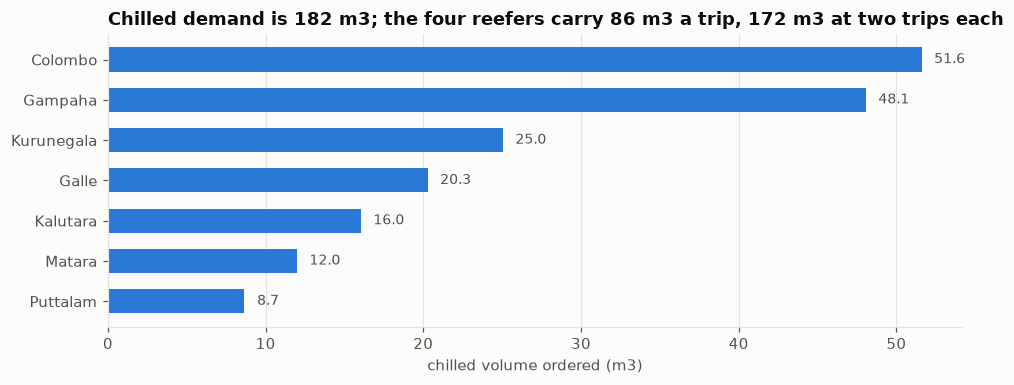

In [3]:
reefer_cap = avail.loc[avail.temp == "reefer", "volume_cap_m3"].sum()
chilled = orders[orders.temp_requirement == "chilled"]
by_district = chilled.groupby("district").order_volume_m3.sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(by_district.index, by_district.values, color=SERIES[0], height=0.6)
for y, val in enumerate(by_district.values):
    ax.text(val + 0.8, y, f"{val:.1f}", va="center", color=INK_SOFT, fontsize=9)
ax.set_xlabel("chilled volume ordered (m3)")
ax.set_title(f"Chilled demand is {chilled.order_volume_m3.sum():.0f} m3; the four reefers carry {reefer_cap:.0f} m3 a trip, {2 * reefer_cap:.0f} m3 at two trips each")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Two facts set up the whole day:
- **Ambient space is plentiful.** 22 ambient trucks and two ambient vans are free, far more than the ambient orders need.
- **Chilled space is not.** Four of the seven reefer trucks and the second reefer van are in the workshop. Even if every remaining reefer ran two full trips, it could not carry all the chilled orders, and far districts like Galle, Matara and Puttalam take most of a reefer's 270 pre-dawn minutes on their own.

So the real decisions of the day are about the reefers.

## 2. Deferrals that no plan can avoid

Before optimising anything, we check which orders cannot be served by any vehicle at all, whatever else happens. An order is impossible when no available vehicle may carry it (depot, reefer and van rules) or when it is bigger than every such vehicle, since orders cannot be split.

In [4]:
def best_vehicle(order):
    ok = [veh for _, veh in prob.vehicles.iterrows() if veh.depot == order.depot
          and (order.temp_requirement != "chilled" or veh.temp == "reefer")
          and (order.parking_constraint != "van_only" or veh.type == "van")]
    return max(ok, key=lambda veh: veh.volume_cap_m3) if ok else None

impossible = []
for _, o in orders.iterrows():
    if not any(prob.can_carry(o, veh) for _, veh in prob.vehicles.iterrows()):
        veh = best_vehicle(o)
        impossible.append({"order_ref": o.order_ref, "outlet_id": o.outlet_id, "brand": o.brand, "district": o.district,
                           "order_m3": o.order_volume_m3, "order_kg": o.order_weight_kg,
                           "largest_allowed_vehicle": veh.vehicle_id, "its_m3": veh.volume_cap_m3, "its_kg": veh.weight_cap_kg})
pd.DataFrame(impossible)

,order_ref,outlet_id,brand,district,order_m3,order_kg,largest_allowed_vehicle,its_m3,its_kg
0,S1-078,OUT070,Style,Kurunegala,40.66,2561.6,VEH011,38.0,7200


Only one order is impossible: **S1-078**, a 40.7 m3 Style order for OUT070 in Kurunegala. The biggest vehicle in the fleet holds 38 m3 and Waypoint does not split orders, so it is deferred whatever we do. The fix is commercial, not operational: ask the outlet to split it into two orders for two days, or send it as two orders tomorrow.

Every other deferral below is a choice the plan makes, and section 5 puts a price on each one.

## 3. The optimiser

**Decisions.** For every order, vehicle and trip (1 or 2) there is a yes or no: does this order ride on this trip? For every trip there is a choice of one brand and district, or none.

**Rules, all hard constraints:**
- each order rides at most once and is never split
- a trip carries one brand in one district
- chilled orders only on reefers, `van_only` outlets only by van, vehicles only serve their own depot
- volume and weight within the vehicle's caps on every trip
- at most two trips per vehicle; planned minutes (drive out, hops between stops, handling allowance) within 270 for Fresh trips and 480 for Style and Tech trips, per vehicle

**Priorities, in order:**

| # | Priority | Why it comes here |
|---|---|---|
| 1 | Serve orders that were deferred yesterday | an outlet should never miss two days in a row |
| 2 | Serve chilled volume | it spoils, and only reefers can carry it |
| 3 | Serve Fresh ambient volume | Fresh shelves must be stocked before 8 AM |
| 4 | Serve the most volume overall | Style and Tech can wait a day more easily than Fresh |
| 5 | Run the fewest second pre-dawn trips | a vehicle that drives back and reloads rarely makes the 8 AM opening (section 6) |
| 6 | Drive the fewest kilometres | cheapest plan among equally good ones |

**One refinement to priority 2.** Many chilled plans are almost tied, and the one with the very most volume is not always the one that reaches the most stores. So the chilled step may give up at most 1% of the best chilled volume, uses that room to get chilled orders to as many stores as possible, and then wins back as much chilled volume as it can while still reaching those stores. Section 3.1 shows what this buys.

**How it is solved.** Chilled orders compete only for the four reefers, so we solve in two stages. Stage 1 packs the chilled orders onto the reefers. Stage 2 keeps those reefer loads and plans every other order on the whole fleet, topping up reefer trips with ambient orders where there is room. This is exact for priorities 1 to 4 as long as stage 2 serves every ambient order, which we check below. Both stages are mixed integer programmes solved with CBC through PuLP.

In [5]:
plan, achieved = al.plan_day(prob, time_limit=120)

steps = pd.DataFrame([(name, label, achieved["stage2"][name], achieved["proven"]["stage2"][name])
                      for name, _, label, _ in al.PRIORITIES], columns=["step", "meaning", "plan value", "proven best"])
steps

,step,meaning,plan value,proven best
0,repeat_deferrals_served,orders deferred yesterday that are served today,10.000,True
1,chilled_m3,chilled volume served (m3),132.586,True
2,chilled_orders,outlets that get their chilled order,18.000,True
3,chilled_m3_for_those_outlets,"chilled volume served, reaching those outlets ...",132.586,True
4,fresh_ambient_m3,Fresh ambient volume served (m3),132.968,True
5,total_m3,total volume served (m3),320.161,True
6,second_fresh_trips,vehicles running a second pre-dawn Fresh trip,4.000,True
7,trip_km,"kilometres driven, depot and back",4218.000,False


In [6]:
ambient = plan[plan.temp_requirement == "ambient"]
unserved_ambient = ambient[(ambient.decision == "deferred") & ~ambient.order_ref.isin([r["order_ref"] for r in impossible])]
print("ambient orders left unserved that some vehicle could carry:", len(unserved_ambient))
assert unserved_ambient.empty, "stage 2 left ambient work behind, so the two-stage solve is no longer exact"

ambient orders left unserved that some vehicle could carry: 0


Every ambient order that fits on any vehicle is served, so the two-stage solve loses nothing on priorities 1 to 4, and all of them are proven best. The only second pre-dawn trips left are the four reefers', which the chilled priority needs. The kilometre step stops on its time limit, so the distance is a good plan rather than a proven minimum; it never trades away anything above it.

### 3.1 Why the 1% matters

The same stage 1 solved with no slack on chilled volume shows what the refinement changes.

In [7]:
reefer_prob = prob.subset(lambda o: o.temp_requirement == "chilled", lambda v: v.temp == "reefer")
strict_priorities = [(n, s, l, 0.0) for n, s, l, _ in al.REEFER_PRIORITIES]
strict, strict_got = al.AllocationModel(reefer_prob).solve(strict_priorities)
ours = plan[plan.temp_requirement == "chilled"]

def chilled_summary(p):
    served = p[p.decision == "served"]
    return {"chilled m3 served": round(served.order_volume_m3.sum(), 1),
            "outlets that get chilled": served.outlet_id.nunique(),
            "reefer km for the chilled loads": int(al.trip_table(served, prob).km.sum()),
            "districts with no chilled delivery": ", ".join(sorted(set(p.district) - set(served.district))) or "none"}

pd.DataFrame({"strict volume first": chilled_summary(strict), "with the 1% refinement": chilled_summary(ours)})

,strict volume first,with the 1% refinement
chilled m3 served,132.8,132.6
outlets that get chilled,17,18
reefer km for the chilled loads,1130,1138
districts with no chilled delivery,Kurunegala,Kurunegala


For a quarter of a cubic metre of chilled goods, about 0.2% of what the reefers carry, the refined plan gets chilled goods to one more store. Setting the slack to zero gives back the strict plan with no other change, so the business can choose.

## 4. The plan

One row per trip. The trip numbers here are the optimiser's; section 6 renumbers them so trip 1 is always the one that leaves first.

In [8]:
trips = al.trip_table(plan, prob)
show = trips.assign(volume_fill=(trips.volume_fill * 100).round(0).astype(int).astype(str) + "%",
                    weight_fill=(trips.weight_fill * 100).round(0).astype(int).astype(str) + "%")
show[["vehicle_id", "trip_id", "type", "temp", "brand", "district", "orders", "chilled_orders",
      "volume_m3", "volume_fill", "weight_fill", "planned_min", "km"]].round(1)

,vehicle_id,trip_id,type,temp,brand,district,orders,chilled_orders,volume_m3,volume_fill,weight_fill,planned_min,km
0,VEH003,1,truck,reefer,Fresh,Gampaha,2,2,21.8,83%,73%,76,63.0
1,VEH003,2,truck,reefer,Fresh,Puttalam,1,1,8.7,33%,29%,188,260.0
2,VEH006,1,truck,reefer,Fresh,Colombo,4,4,32.8,98%,82%,109,36.0
3,VEH006,2,truck,reefer,Fresh,Gampaha,4,4,26.2,79%,69%,125,77.0
4,VEH007,1,truck,reefer,Fresh,Galle,1,1,16.5,85%,76%,118,240.0
5,VEH007,2,truck,reefer,Fresh,Kalutara,3,3,16.0,83%,81%,134,114.0
6,VEH008,1,truck,ambient,Fresh,Gampaha,6,0,19.7,89%,96%,173,91.0
7,VEH008,2,truck,ambient,Tech,Matara,1,0,1.6,7%,13%,180,320.0
8,VEH009,1,truck,ambient,Fresh,Galle,6,0,15.3,51%,47%,242,290.0
9,VEH011,1,truck,ambient,Fresh,Colombo,9,0,31.4,83%,83%,226,56.0


In [9]:
served = plan[plan.decision == "served"]
summary = pd.DataFrame({
    "orders": plan.groupby("temp_requirement").order_ref.size(),
    "served": served.groupby("temp_requirement").order_ref.size(),
    "m3 ordered": plan.groupby("temp_requirement").order_volume_m3.sum(),
    "m3 served": served.groupby("temp_requirement").order_volume_m3.sum(),
})
summary.loc["all"] = summary.sum()
summary["share of m3 served"] = (summary["m3 served"] / summary["m3 ordered"] * 100).round(1).astype(str) + "%"
print(f"{len(trips)} trips on {trips.vehicle_id.nunique()} vehicles, {trips.km.sum():.0f} km")
summary.round(1)

24 trips on 17 vehicles, 4218 km


,orders,served,m3 ordered,m3 served,share of m3 served
temp_requirement,,,,,
ambient,59.0,58.0,228.2,187.6,82.2%
chilled,26.0,18.0,181.6,132.6,73.0%
all,85.0,76.0,409.9,320.2,78.1%


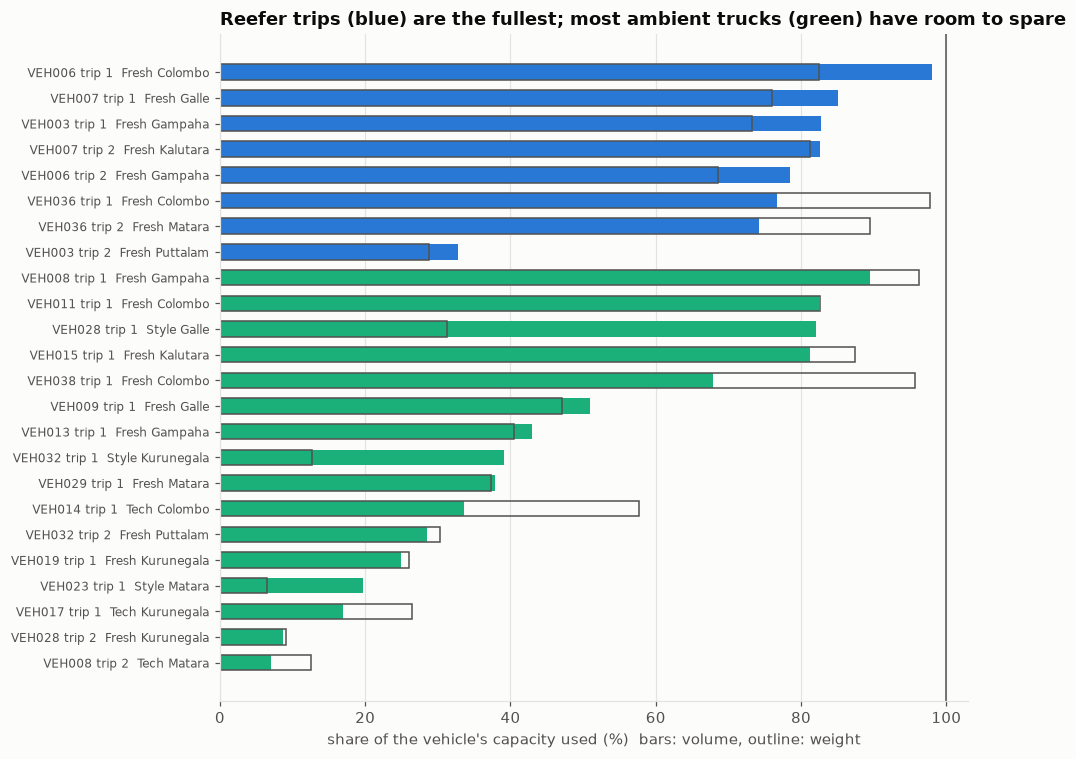

In [10]:
t = trips.sort_values(["temp", "volume_fill"])
labels = t.vehicle_id + " trip " + t.trip_id.astype(str) + "  " + t.brand + " " + t.district
colors = np.where(t.temp == "reefer", SERIES[0], SERIES[2])

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, t.volume_fill * 100, color=colors, height=0.6)
ax.barh(labels, t.weight_fill * 100, color="none", edgecolor=INK_SOFT, height=0.6, linewidth=1)
ax.axvline(100, color=INK_SOFT, linewidth=1)
ax.set_xlabel("share of the vehicle's capacity used (%)  bars: volume, outline: weight")
ax.set_title("Reefer trips (blue) are the fullest; most ambient trucks (green) have room to spare")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

## 5. Every deferral, explained

Each deferred order gets a reason code and, where it was a choice, a price. The price comes from re-solving stage 1 with that one order forced onto a reefer and every chilled priority still in place: how many fewer stores would get their chilled goods, and how much chilled volume would change.

| Code | Meaning |
|---|---|
| `TOO_BIG_FOR_ANY_VEHICLE` | bigger than every vehicle allowed to carry it; unavoidable |
| `REEFER_CAPACITY` | chilled space is the binding limit; serving it pushes out other chilled volume |

In [11]:
base_chilled = ours.loc[ours.decision == "served", "order_volume_m3"].sum()
base_outlets = ours.loc[ours.decision == "served", "outlet_id"].nunique()
chilled_steps = [p for p in al.REEFER_PRIORITIES if p[0] != "trip_km"]
rows = []
for _, o in plan[plan.decision == "deferred"].iterrows():
    row = {"order_ref": o.order_ref, "outlet_id": o.outlet_id, "brand": o.brand, "district": o.district,
           "temp": o.temp_requirement, "m3": o.order_volume_m3, "days_since_served": o.days_since_last_served}
    if o.order_ref in [r["order_ref"] for r in impossible]:
        row.update(reason="TOO_BIG_FOR_ANY_VEHICLE")
    else:
        forced, _ = al.AllocationModel(reefer_prob).solve(chilled_steps, force={o.order_ref: 1})
        fs = forced[forced.decision == "served"]
        row.update(reason="REEFER_CAPACITY",
                   chilled_stores_change_if_served=fs.outlet_id.nunique() - base_outlets,
                   chilled_m3_change_if_served=round(fs.order_volume_m3.sum() - base_chilled, 2))
    rows.append(row)
deferrals = pd.DataFrame(rows).sort_values(["reason", "chilled_m3_change_if_served"], ascending=[True, False])
deferrals.round(2)

,order_ref,outlet_id,brand,district,temp,m3,days_since_served,reason,chilled_stores_change_if_served,chilled_m3_change_if_served
2,S1-021,OUT013,Fresh,Colombo,chilled,9.90,1,REEFER_CAPACITY,0.0,-0.19
3,S1-056,OUT053,Fresh,Galle,chilled,3.75,2,REEFER_CAPACITY,0.0,-0.54
5,S1-071,OUT065,Fresh,Kurunegala,chilled,12.04,1,REEFER_CAPACITY,0.0,-0.96
6,S1-073,OUT066,Fresh,Kurunegala,chilled,5.77,1,REEFER_CAPACITY,0.0,-0.96
7,S1-075,OUT067,Fresh,Kurunegala,chilled,7.24,2,REEFER_CAPACITY,0.0,-0.96
0,S1-003,OUT002,Fresh,Colombo,chilled,1.84,1,REEFER_CAPACITY,1.0,-1.63
1,S1-005,OUT003,Fresh,Colombo,chilled,1.72,2,REEFER_CAPACITY,1.0,-1.63
4,S1-064,OUT060,Fresh,Matara,chilled,6.78,1,REEFER_CAPACITY,0.0,-8.95
8,S1-078,OUT070,Style,Kurunegala,ambient,40.66,2,TOO_BIG_FOR_ANY_VEHICLE,NaN,NaN


How to read the price. Serving a deferred chilled order always pushes other chilled goods off a reefer, so every swap costs chilled volume. Most swaps keep the same number of stores and cost under 1 m3; the Matara order would cost about 9 m3. The two `van_only` Colombo stores are the exception: serving one of them would reach one more store, but only by giving up 1.6 m3, more than the 1% the policy allows, because the single reefer van has to drop a bigger order to carry it. When a store manager pushes back, this table is the dispatcher's answer: the swap is possible, and here is what it costs.

None of the deferred orders were also deferred yesterday, so priority 1 holds in full: all ten repeat deferrals ride today. Every order deferred today becomes a priority 1 order tomorrow.

## 6. Will it arrive on time?

The planning standard counts minutes but does not look at the clock. It leaves out the drive back to the depot between two trips, and it ignores store opening times, so a truck that reaches a store at 04:10 when it opens at 05:30 simply waits. We replay every vehicle's day on the clock:
- Fresh trips start from 03:30, Style and Tech trips from 07:30
- a vehicle leaves no earlier than it needs to reach its first store as it opens
- stops are visited in the order with the fewest late arrivals
- a second trip in the same window loads only after the first one drives back
- when a vehicle has two trips in one window, both orders are tried and the better one is kept

We replay twice: once on the planning standard (free-flow drive times, handling exactly as allowed) and once on a **typical day**, using the median drive-time and handling ratios and the median depot delay from the route history, the same history the Task 1 models learned from.

In [12]:
history = load_processed("stops")
history = history[history.service_min.notna()].merge(load_processed("service_allowance"), on=["brand", "dock_type"])
travel_ratio = (history.actual_travel_duration_min / history.planned_travel_duration_min.clip(lower=1)
                ).groupby([history.brand, history.district]).median().to_dict()
service_ratio = (history.service_min / history.service_allowance_min).groupby([history.brand, history.dock_type]).median().to_dict()
first_legs = history[history.seq == 0]
depart_delay = float((first_legs.actual_depart_time_min - first_legs.planned_depart_time_min).median())

tl_standard = al.timeline(plan, prob)
tl_typical = al.timeline(plan, prob, travel_ratio=travel_ratio, service_ratio=service_ratio, depart_delay=depart_delay)
pd.DataFrame({
    "late stops": [tl_standard.late.sum(), tl_typical.late.sum()],
    "late chilled stops": [(tl_standard.late & (tl_standard.temp_requirement == "chilled")).sum(),
                           (tl_typical.late & (tl_typical.temp_requirement == "chilled")).sum()],
    "served stops": [len(tl_standard), len(tl_typical)],
}, index=["planning standard", "typical day"])

,late stops,late chilled stops,served stops
planning standard,5,5,76
typical day,11,7,76


In [13]:
cols = ["vehicle_id", "run", "brand", "district", "order_ref", "outlet_id", "temp_requirement",
        "depart", "arrive", "window_open_time", "window_close_time", "late_by_min"]
tl_standard.loc[tl_standard.late, cols].round(0)

,vehicle_id,run,brand,district,order_ref,outlet_id,temp_requirement,depart,arrive,window_open_time,window_close_time,late_by_min
2,VEH003,2,Fresh,Puttalam,S1-083,OUT074,chilled,05:23,08:16,05:30,08:00,16.0
9,VEH006,2,Fresh,Gampaha,S1-033,OUT029,chilled,06:49,08:14,05:30,08:00,14.0
10,VEH006,2,Fresh,Gampaha,S1-031,OUT028,chilled,06:49,08:38,03:00,08:00,38.0
14,VEH007,2,Fresh,Galle,S1-058,OUT054,chilled,07:14,08:57,05:00,07:30,87.0
70,VEH036,2,Fresh,Matara,S1-067,OUT062,chilled,06:10,08:27,05:30,08:00,27.0


On the standard itself, the late stops all sit on **second pre-dawn trips**. The standard lets each reefer run two trips in the 270 minutes, but once the drive back and the store opening times are counted, the second trip reaches some of its stores after 08:00. Spare ambient trucks never run a second pre-dawn trip, which is what priority 5 is for. On a typical day, with real drive times about 30 to 70% above free flow, more stops slip.

This does not change the plan, which follows Waypoint's planning standard. It changes what the dispatcher does with it:
- the late stops are known the evening before, so their store managers can be told to expect a late morning delivery and plan staff for it
- the drivers of second trips get the clock times from this replay, not the planning minutes
- these stops are exactly the ones the Task 1 late-risk model should watch on the day

The plan's trip numbers now follow the run order from the replay, so trip 1 is always the one that leaves first.

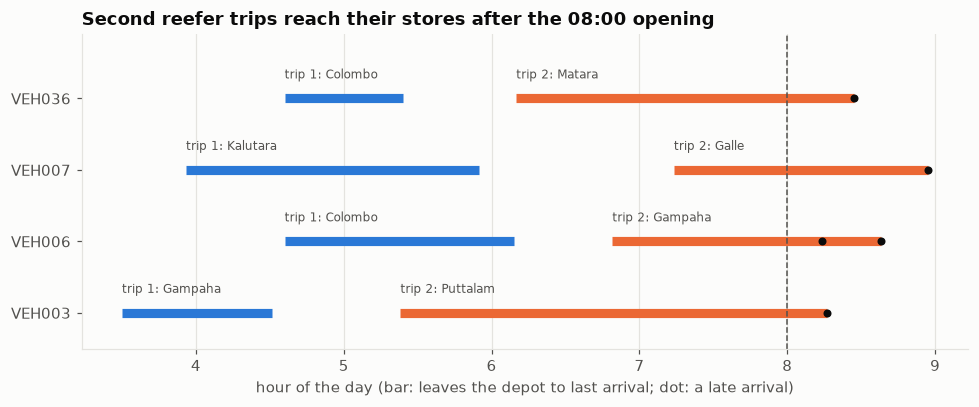

In [14]:
plan = al.renumber_trips(plan, tl_standard)
tl_standard = al.timeline(plan, prob)
trips = al.trip_table(plan, prob)

reefers = tl_standard[tl_standard.vehicle_id.isin(avail.loc[avail.temp == "reefer", "vehicle_id"])]
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (vid, g) in enumerate(reefers.groupby("vehicle_id")):
    for run, r in g.groupby("run"):
        start, end = r.depart_min.min() / 60, r.arrive_min.max() / 60
        ax.plot([start, end], [i, i], color=SERIES[run - 1], linewidth=6, solid_capstyle="butt")
        ax.text(start, i + 0.28, f"trip {run}: {r.district.iloc[0]}", fontsize=8, color=INK_SOFT)
    late = g[g.late]
    ax.scatter(late.arrive_min / 60, [i] * len(late), color=INK, zorder=3, s=18)
ax.axvline(8, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_ylim(-0.5, reefers.vehicle_id.nunique() - 0.1)
ax.set_yticks(range(reefers.vehicle_id.nunique()), sorted(reefers.vehicle_id.unique()))
ax.set_xlabel("hour of the day (bar: leaves the depot to last arrival; dot: a late arrival)")
ax.set_title("Second reefer trips reach their stores after the 08:00 opening")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 7. What a workshop repair is worth

Five reefers are in the workshop: four trucks and one van. If the workshop can return one of them for the morning run, which should it be? We re-solve stage 1 with each one added back. Only stage 1 is needed, because ambient work is already fully served.

In [15]:
workshop_reefers = workshop.loc[workshop.temp == "reefer", "vehicle_id"].tolist()
repair = []
for vid in workshop_reefers:
    p2 = al.load_problem(scenarios, fleet, vehicles, travel, allowance, scenario="S1", extra_vehicles=[vid])
    r2 = p2.subset(lambda o: o.temp_requirement == "chilled", lambda v: v.temp == "reefer")
    pl2, _ = al.AllocationModel(r2).solve(al.REEFER_PRIORITIES)
    s2 = pl2[pl2.decision == "served"]
    veh = vehicles.set_index("vehicle_id").loc[vid]
    repair.append({"vehicle_id": vid, "type": veh.type, "m3": veh.volume_cap_m3,
                   "extra chilled m3": round(s2.order_volume_m3.sum() - base_chilled, 1),
                   "extra outlets with chilled": s2.outlet_id.nunique() - ours[ours.decision == "served"].outlet_id.nunique()})
repair = pd.DataFrame(repair).sort_values("extra chilled m3", ascending=False)
repair

,vehicle_id,type,m3,extra chilled m3,extra outlets with chilled
2,VEH004,truck,33.4,35.3,5
3,VEH005,truck,33.4,35.3,5
0,VEH001,truck,26.4,34.8,5
1,VEH002,truck,21.1,33.3,5
4,VEH035,van,7.0,9.6,2


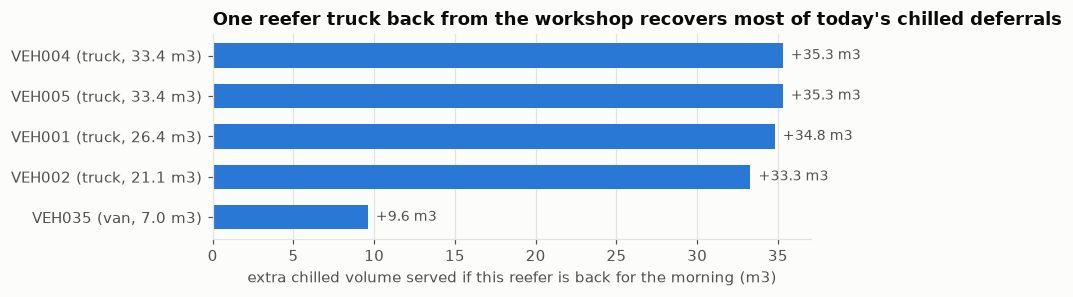

In [16]:
fig, ax = plt.subplots(figsize=(8, 2.8))
r = repair.sort_values("extra chilled m3")
ax.barh(r.vehicle_id + " (" + r.type + ", " + r.m3.astype(str) + " m3)", r["extra chilled m3"], color=SERIES[0], height=0.6)
for y, val in enumerate(r["extra chilled m3"]):
    ax.text(val + 0.5, y, f"+{val:.1f} m3", va="center", color=INK_SOFT, fontsize=9)
ax.set_xlabel("extra chilled volume served if this reefer is back for the morning (m3)")
ax.set_title("One reefer truck back from the workshop recovers most of today's chilled deferrals")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Any one of the large reefer trucks recovers most of the chilled volume deferred today. The reefer van is worth much less in volume, but it is the only way to reach the `van_only` outlets with chilled goods, so it matters for those three stores. This is the ranking to give the workshop on a peak day: large reefer trucks first, then the reefer van.